# Grain Seasonality — a quantitative teardown 🔬
### A 36-cell Bonferroni month table · per-grain and pooled Welch/HAC splits · a block-bootstrap CI · the ETF-vs-futures roll-drag test · a costed calendar timer · a coin-flip hit-rate test · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **grain prices carry a spring weather-risk premium that decays into harvest — has a real mechanism (Working's theory of storage) and a century of trading-floor conviction behind it. The job here is to test it on the instruments a retail account can actually hold, with the multiple-testing correction the 3-grain × 12-month grid demands.

> ⚠️ **Data note.** CORN/WEAT/SOYB daily adjusted closes + ZC=F/ZW=F/ZS=F daily raw closes, yfinance, 2011-10-03 → 2026-06-30 (176 monthly observations per series); **hardcoded USDA crop-progress windows** per grain (facts, no network). No survivorship (single continuously-listed tickers). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `81eafd725d20` / `38378019b4f4` / `a1a9d64ef5f8` / `1d148da3b3a1` / `6b8a61301bbf` / `c488e2ab74e4`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from grain_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    ETF, FUT = data.load_real()
    MONTHLY = {g: st.monthly_log_returns(ETF[g]) for g in data.GRAINS}
    FUT_MONTHLY = {g: st.monthly_log_returns(FUT[g]) for g in data.GRAINS}
else:
    ETF = FUT = MONTHLY = FUT_MONTHLY = None
print("real cache present:", HAVE_REAL, "| grains:", data.GRAINS,
      "| months/grain:", (0 if MONTHLY is None else {g: len(MONTHLY[g]) for g in data.GRAINS}))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2011-10-03', 'end': '2026-06-30', 'n_months': 176, 'bonf_crit': 4.05, 'bonf_survive': 0, 'bonf_n': 36, 'best': {'corn': (10, 1.37, 1.6), 'wheat': (10, 0.96, 1.8), 'soy': (10, 1.26, 1.05)}, 'worst': {'corn': (7, -2.45, -0.98), 'wheat': (8, -3.21, -1.68), 'soy': (7, -1.53, -1.13)}, 'top_hac': {'wheat_nov': -2.78, 'corn_nov': -2.45, 'wheat_aug': -2.27}, 'sh': {'corn': (-2.29, 29, -0.38, 43, -1.92, -1.2), 'wheat': (0.2, 45, -2.1, 29, 2.3, 1.13), 'soy': (-1.03, 28, -0.02, 43, -1.01, -0.84)}, 'pooled_spring': -0.85, 'pooled_harvest': -0.68, 'pooled_spread': -0.17, 'pooled_t': -0.19, 'pooled_n_spring': 102, 'pooled_n_harvest': 115, 'ci_lo': -1.97, 'ci_hi': 1.75, 'ci_boot': 5000, 'drag': {'corn': (-53.8, -25.5, -28.3, -0.89), 'wheat': (-94.8, -4.5, -90.3, -5.09), 'soy': (5.3, -4.4, 9.8, 0.45)}, 'timer': {'corn': (-0.35, -7.8, -0.25, -4.3, -0.28, -4.6), 'wheat': (-0.49, -13.2, 0.27, 3.3, 0.25, 2.9), 'soy': (0.04, -0.8, -0.18, -2.4, -0.22, -2.8), 'pooled': (-0.34, -6.9, -0.03, -0.5, -0.08, -0.8)}, 'hit_k': 100, 'hit_n': 216, 'hit_rate': 46.3, 'hit_lo': 39.8, 'hit_hi': 53.0, 'hit_t': -0.09, 'syn_null_mean': 0.36, 'syn_null_sd': 1.02, 'syn_null_fire': 1, 'syn_planted_t': 5.64, 'fp_corn': '81eafd725d20', 'fp_wheat': '38378019b4f4', 'fp_soy': 'a1a9d64ef5f8', 'fp_zc': '1d148da3b3a1', 'fp_zw': '6b8a61301bbf', 'fp_zs': 'c488e2ab74e4'}


real cache present: True | grains: ('corn', 'wheat', 'soy') | months/grain: {'corn': 176, 'wheat': 176, 'soy': 176}


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | pooled spring-vs-harvest spread **-0.17%/mo**, Welch **t = -0.19**, bootstrap CI **[-1.97%, +1.75%]**; **0/36** month×grain cells clear the Bonferroni bar (\|t\| ≥ 4.05) |
| **Tradability** | `MIRAGE` | WEAT roll drag **-90.3 bps/mo** (t = -5.09); pooled timer net Sharpe **-0.08** |
| **Beats a coin?** | `BUSTED` | active-leg hit rate **100/216 = 46.3%** (Wilson [39.8%, 53.0%]), t = -0.09 |

> 💡 In plain words: the storage-cycle mechanism is real economics; the ETF tape shows no certified trace of it, and what little the timer earns is a cash-drag illusion, not skill.

## 1 · The claim, steelmanned

Let $r_{g,t}$ be grain $g$'s monthly log return and $S_g, H_g \subset \{1..12\}$ its own USDA-calendar spring (weather-scare) and harvest month sets. The claims:

- **H₁ (level).** $E[r_{g,t} \mid m_t \in S_g] \gg E[r_{g,t} \mid m_t \in H_g]$ for each grain, and pooled across grains.
- **H₂ (concentration).** The seasonal is a genuine calendar effect, not one lucky month out of the 3×12 = 36 cells on the board.
- **H₃ (tradability).** A calendar-known long-spring/short-harvest timer on the *ETF* earns net of costs and beats a coin on its active legs.
- **H₄ (roll).** Whatever the raw futures curve shows, the ETF the retail account actually holds captures most of it (the roll doesn't eat the edge).

We find **H₁ rejected** (pooled t = −0.19, wrong sign in 2/3 grains), **H₂ rejected** (0/36 Bonferroni survivors), **H₃ rejected** (46.3% active-leg hit rate, net Sharpe negative pooled) and **H₄ rejected** for wheat specifically (a certified, large roll drag).

## 2 · So what? — inference design

Calendar months within a year are **not** independent draws (weather years are autocorrelated across adjacent months), so every per-month test reports both a naive one-sample *t* and a **Newey-West (HAC)** *t*. Testing 3 grains × 12 months at once is 36 simultaneous comparisons, so the honest bar is **Bonferroni**-corrected: $\alpha/36 \approx 0.0014$, which at $df \approx 13$ needs $|t| \ge 4.05$ — far stricter than the naive $|t| \ge 2$. The spring-vs-harvest headline uses a **Welch** two-sample *t* (unequal variances, unequal group sizes by construction) plus a **circular block-bootstrap** (12-month blocks, respecting each grain's own annual seasonal structure) for a distribution-free CI on the pooled spread.

## 3 · How we'd know — the protocol

- **Tape.** CORN/WEAT/SOYB adjusted closes + ZC=F/ZW=F/ZS=F raw closes, 2011-10-03 → 2026-06-30, resampled to **176 monthly observations per series**. As-of 2026-06-30 (last complete month).
- **Calendar.** Hardcoded USDA NASS crop-progress windows per grain (`GRAIN_CALENDAR` in `data.py`) — planting / weather-scare / harvest, facts not fit.
- **Headline.** Per-month naive + HAC *t* (36 cells, Bonferroni-corrected); best/worst month Welch *t* vs rest, per grain; spring-vs-harvest Welch *t*, per grain and pooled, with a 5,000-draw block-bootstrap CI.
- **Execution (calendar-known).** The seasonal timer's position is set from the fixed USDA windows alone — no signal-to-trade lag is needed, because the calendar repeats every year and is known at the start of it.
- **Costs.** 4 one-way legs/yr × 10 bps × NAV, spread evenly across the 12 months.
- **Roll cross-check.** ETF monthly return minus the roll-naive futures-splice monthly return, one-sample *t* of the gap — sizes what the ETF's own mechanics already take before any calendar math starts.
- **Control.** i.i.d. synthetic monthly-return world, planted spring/harvest spread knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The 36-cell month table and the Bonferroni bar

Per-grain, per-month naive + HAC *t*-stats. The Bonferroni-corrected bar for 36 simultaneous tests dwarfs the naive |t| ≥ 2 line.

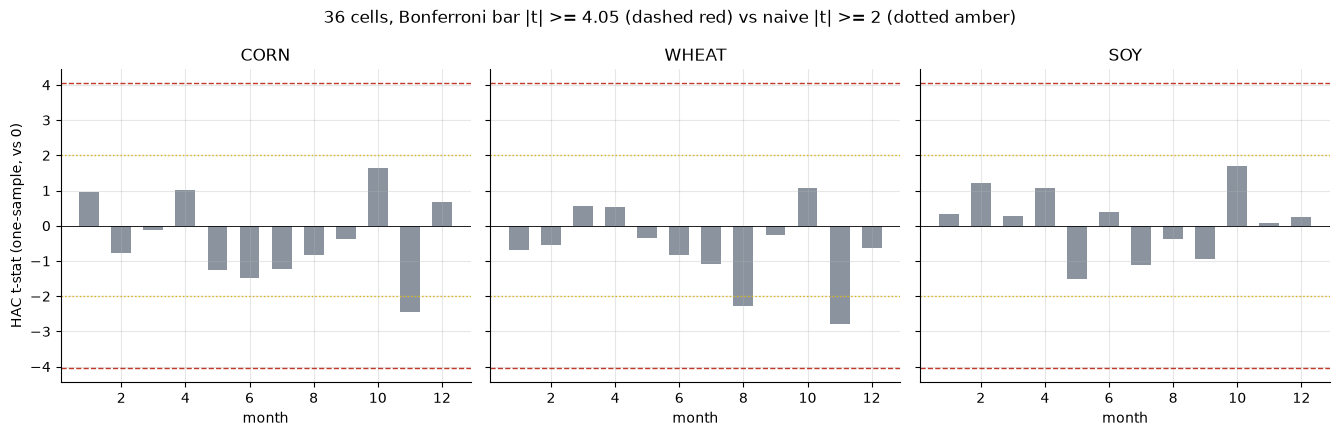

cells clearing Bonferroni: 0/36


In [2]:
grains = list(data.GRAINS)
if HAVE_REAL:
    crit = st.bonferroni_crit_t(36, df=13)
    tabs = {g: st.month_stats(MONTHLY[g]) for g in grains}
    hac = {g: tabs[g]['tstat_hac'].to_numpy() for g in grains}
else:
    crit = R['bonf_crit']
    hac = {'corn': [0.97,-0.78,-0.12,1.02,-1.26,-1.47,-1.24,-0.82,-0.38,1.63,-2.45,0.68],
           'wheat': [-0.68,-0.55,0.57,0.52,-0.36,-0.84,-1.09,-2.27,-0.25,1.08,-2.78,-0.64],
           'soy': [0.33,1.22,0.29,1.08,-1.52,0.40,-1.10,-0.37,-0.94,1.71,0.07,0.26]}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharey=True)
for ax, g in zip(axes, grains):
    t = hac[g]
    cols = [RED if abs(v) >= crit else GREY for v in t]
    ax.bar(range(1, 13), t, color=cols, width=.62)
    ax.axhline(crit, ls='--', c=RED, lw=1); ax.axhline(-crit, ls='--', c=RED, lw=1)
    ax.axhline(2, ls=':', c=AMBER, lw=1); ax.axhline(-2, ls=':', c=AMBER, lw=1)
    ax.axhline(0, c='k', lw=.6)
    ax.set_title(g.upper()); ax.set_xlabel('month')
axes[0].set_ylabel('HAC t-stat (one-sample, vs 0)')
fig.suptitle(f'36 cells, Bonferroni bar |t| >= {crit:.2f} (dashed red) vs naive |t| >= 2 (dotted amber)')
plt.tight_layout(); plt.show()
n_survive = sum(int(abs(v) >= crit) for g in grains for v in hac[g])
print(f'cells clearing Bonferroni: {n_survive}/36')

**0/36** cells clear the Bonferroni bar (|t| ≥ 4.05). The largest *nominal* HAC t-stats — WEAT-November (-2.78), CORN-November (-2.45), WEAT-August (-2.27) — clear only the naive |t| ≥ 2 line, not the corrected one, and all three are *negative*: bearish months, not the claimed spring highs. This is exactly the shape a null grid of 36 tests should produce — a couple of nominal-looking cells by chance, none surviving correction.

### 4b · Best/worst month and spring-vs-harvest, per grain

Welch *t* of the single best/worst month vs every other month pooled, and of the grain's own spring vs harvest window.

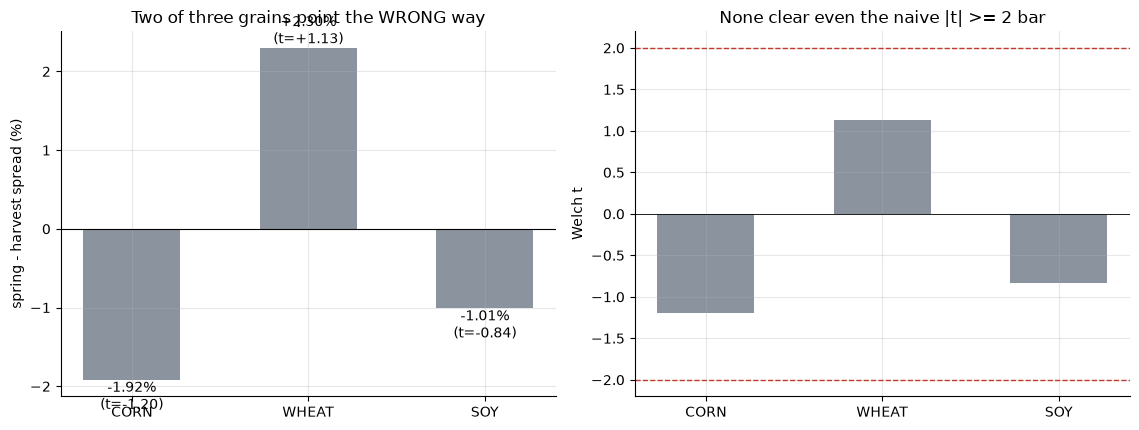

{'corn': (-1.92, -1.2), 'wheat': (2.3, 1.13), 'soy': (-1.01, -0.84)}


In [3]:
if HAVE_REAL:
    bw = {g: st.best_worst_vs_rest(MONTHLY[g]) for g in grains}
    sh = {g: st.spring_harvest_tstat(MONTHLY[g], data.SPRING_MONTHS[g], data.HARVEST_MONTHS[g]) for g in grains}
    spreads = [sh[g]['spread']*100 for g in grains]
    spread_ts = [sh[g]['t'] for g in grains]
else:
    spreads = [R['sh'][g][4] for g in grains]
    spread_ts = [R['sh'][g][5] for g in grains]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
cols = [RED if abs(t) >= 2 else GREY for t in spread_ts]
a1.bar([g.upper() for g in grains], spreads, color=cols, width=.55)
for i, (v, t) in enumerate(zip(spreads, spread_ts)):
    a1.annotate(f'{v:+.2f}%\n(t={t:+.2f})', (i, v), ha='center', va='bottom' if v>=0 else 'top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('spring - harvest spread (%)')
a1.set_title('Two of three grains point the WRONG way')
a2.bar([g.upper() for g in grains], spread_ts, color=cols, width=.55)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.6)
a2.set_ylabel('Welch t'); a2.set_title('None clear even the naive |t| >= 2 bar')
plt.tight_layout(); plt.show()
print({g: (round(spreads[i],2), round(spread_ts[i],2)) for i, g in enumerate(grains)})

> 💡 In plain words: corn's spread is −1.92% (t = −1.20) and soy's is −1.01% (t = −0.84) — both *against* the claim's sign — and wheat's, the only grain pointing the right way, is +2.30% at t = +1.13. None is close to significant even before any multiple-testing penalty.

### 4c · The pooled headline and its bootstrap CI

Pool spring-tagged and harvest-tagged monthly returns across all three grains; a circular block-bootstrap (12-month blocks per grain, so each resample respects a grain's own annual seasonal structure) gives a distribution-free CI on the spread.

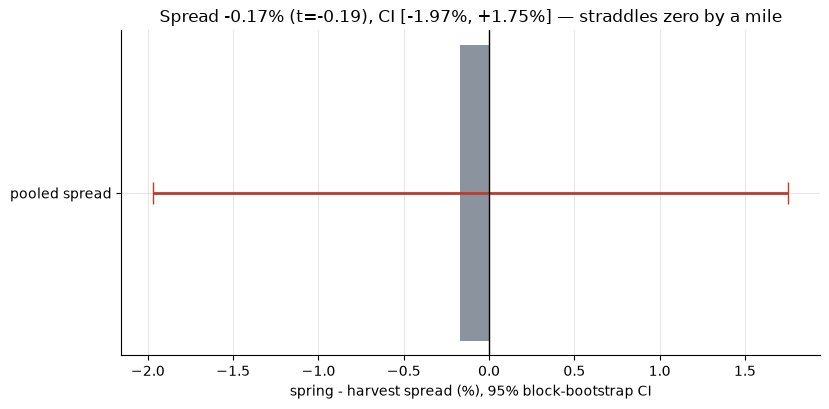

pooled spread -0.17%  t=-0.19  CI [-1.97%, +1.75%]


In [4]:
if HAVE_REAL:
    pooled = st.pooled_spring_harvest(MONTHLY, data.SPRING_MONTHS, data.HARVEST_MONTHS)
    ci = st.pooled_spread_bootstrap_ci(MONTHLY, data.SPRING_MONTHS, data.HARVEST_MONTHS)
    spread, t, lo, hi = pooled['spread']*100, pooled['t'], ci['lo']*100, ci['hi']*100
else:
    spread, t, lo, hi = R['pooled_spread'], R['pooled_t'], R['ci_lo'], R['ci_hi']
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.barh(['pooled spread'], [spread], color=GREY, height=.4)
ax.errorbar([spread], ['pooled spread'], xerr=[[spread-lo],[hi-spread]], fmt='none', ecolor=RED, capsize=8, lw=2)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('spring - harvest spread (%), 95% block-bootstrap CI')
ax.set_title(f'Spread {spread:+.2f}% (t={t:+.2f}), CI [{lo:+.2f}%, {hi:+.2f}%] — straddles zero by a mile')
plt.tight_layout(); plt.show()
print(f'pooled spread {spread:+.2f}%  t={t:+.2f}  CI [{lo:+.2f}%, {hi:+.2f}%]')

> 💡 In plain words: the pooled point estimate (-0.17%) is smaller than the width of its own confidence interval by an order of magnitude. H₁ is rejected across the board — not "weak," genuinely absent on this tape.

### 4d · The ETF's own roll — the 'contango' caveat, sized

Each ETF's monthly return minus the roll-naive futures-splice monthly return, one-sample *t* of the gap. A real cost, independent of any calendar view.

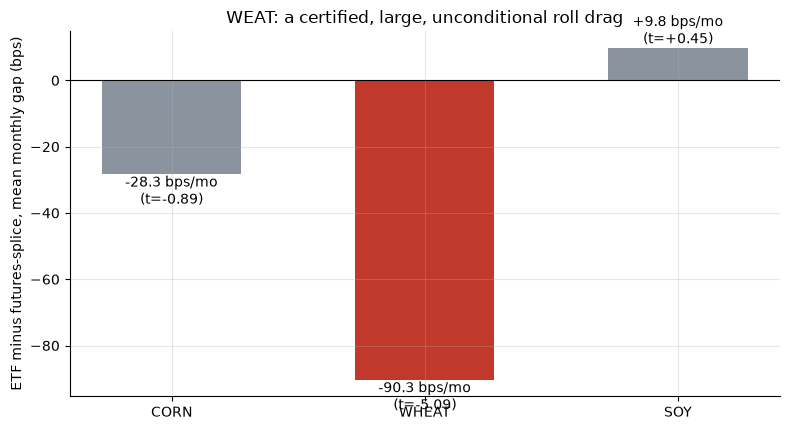

{'corn': (-28.3, -0.89), 'wheat': (-90.3, -5.09), 'soy': (9.8, 0.45)}


In [5]:
if HAVE_REAL:
    drag = {g: st.roll_drag(MONTHLY[g], FUT_MONTHLY[g]) for g in grains}
    d = [drag[g]['drag_bps'] for g in grains]; dt = [drag[g]['t'] for g in grains]
else:
    d = [R['drag'][g][2] for g in grains]; dt = [R['drag'][g][3] for g in grains]
fig, ax = plt.subplots(figsize=(8.0, 4.4))
cols = [RED if abs(t) >= 2 else GREY for t in dt]
ax.bar([g.upper() for g in grains], d, color=cols, width=.55)
for i, (v, t) in enumerate(zip(d, dt)): ax.annotate(f'{v:+.1f} bps/mo\n(t={t:+.2f})', (i, v),
    ha='center', va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('ETF minus futures-splice, mean monthly gap (bps)')
ax.set_title('WEAT: a certified, large, unconditional roll drag')
plt.tight_layout(); plt.show()
print({g: (round(x,1), round(y,2)) for g, x, y in zip(grains, d, dt)})

> 💡 In plain words: WEAT's drag (-90.3 bps/mo, t = -5.09) clears |t| ≥ 2 easily and is, in absolute size, bigger than every spring-vs-harvest spread this study measured — the roll is a *bigger and more certain* effect than the seasonal it would have to beat. Corn's drag is smaller and not certified; soy's is nominally positive — roll drag is a property of each grain's own curve shape, not a universal tax.

### 4e · The costed timer and the coin-flip test

Long spring, short harvest, cash otherwise (no execution lag — the calendar repeats every year); 4 one-way legs/yr × 10 bps × NAV. The honest read isolates the *active* legs from the cash months.

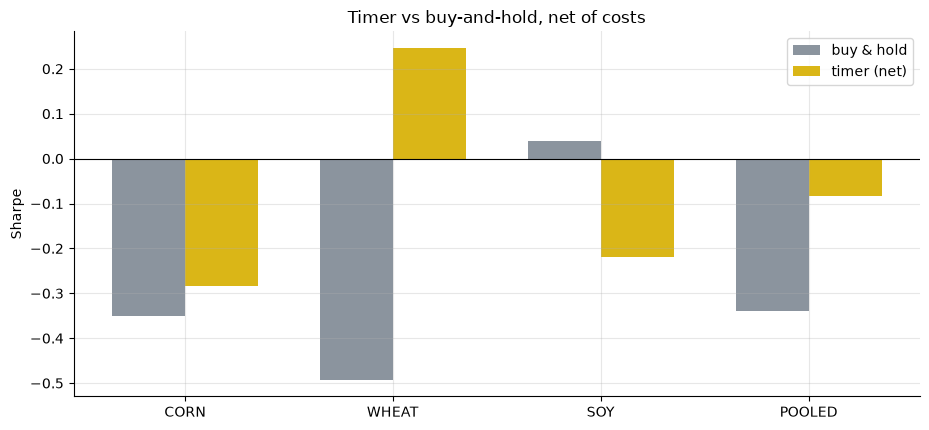

{'corn': (-0.349614973737806, -0.25357729844191657, -0.2831195704102979), 'wheat': (-0.4926011455278627, 0.26914587318806016, 0.2465303545195032), 'soy': (0.03821595191589343, -0.18062721005700338, -0.21850097370766103), 'pooled': (-0.3402295873873623, -0.026809220873865537, -0.08220802007721596)}


In [6]:
if HAVE_REAL:
    rows = {}
    for g in grains:
        r = MONTHLY[g]
        timer = st.seasonal_timer(r, data.SPRING_MONTHS[g], data.HARVEST_MONTHS[g])
        net = st.apply_costs(timer, n_trades_per_year=4, cost_bps_one_way=10.0)
        rows[g] = (st.summary(r)['sharpe'], st.summary(timer)['sharpe'], st.summary(net)['sharpe'])
    pooled_bh = sum(MONTHLY[g].reindex(MONTHLY['corn'].index) for g in grains) / 3
    pooled_timer = sum(st.seasonal_timer(MONTHLY[g], data.SPRING_MONTHS[g], data.HARVEST_MONTHS[g]) for g in grains) / 3
    pooled_net = st.apply_costs(pooled_timer, n_trades_per_year=4, cost_bps_one_way=10.0)
    rows['pooled'] = (st.summary(pooled_bh)['sharpe'], st.summary(pooled_timer)['sharpe'], st.summary(pooled_net)['sharpe'])
else:
    rows = {g: (R['timer'][g][0], R['timer'][g][2], R['timer'][g][4]) for g in list(grains)+['pooled']}
labels = [g.upper() for g in grains] + ['POOLED']
bh = [rows[g][0] for g in list(grains)+['pooled']]
tn = [rows[g][2] for g in list(grains)+['pooled']]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x - w/2, bh, w, label='buy & hold', color=GREY)
ax.bar(x + w/2, tn, w, label='timer (net)', color=AMBER)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Sharpe'); ax.set_title('Timer vs buy-and-hold, net of costs')
ax.legend(); plt.tight_layout(); plt.show()
print(rows)

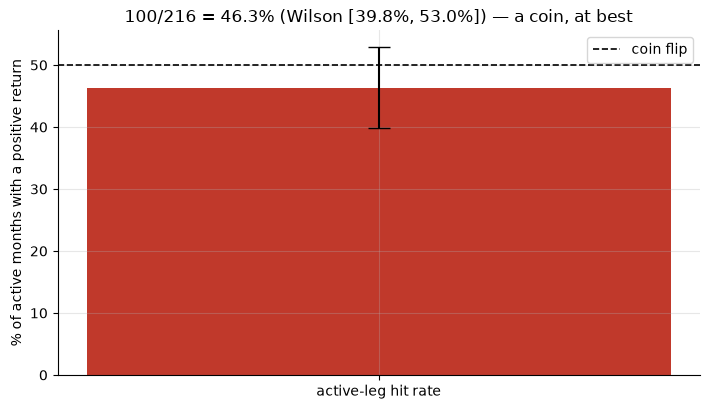

hit rate 100/216 = 46.3%  Wilson [39.8%, 53.0%]  t=-0.09


In [7]:
if HAVE_REAL:
    active = []
    for g in grains:
        timer = st.seasonal_timer(MONTHLY[g], data.SPRING_MONTHS[g], data.HARVEST_MONTHS[g])
        active.append(timer[timer != 0.0].dropna())
    allx = pd.concat(active).to_numpy()
    k, n = int((allx > 0).sum()), len(allx)
    rate = k / n
    t = st._one_sample_t(allx)
else:
    k, n, rate, t = R['hit_k'], R['hit_n'], R['hit_rate']/100, R['hit_t']
z = 1.96; p = rate; z2 = z*z
mid = (p + z2/(2*n)) / (1 + z2/n)
half = z * np.sqrt(p*(1-p)/n + z2/(4*n*n)) / (1 + z2/n)
lo, hi = mid - half, mid + half
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(['active-leg hit rate'], [rate*100], color=RED if rate < 0.5 else AMBER, width=.4)
ax.errorbar([0], [rate*100], yerr=[[  (rate-lo)*100],[(hi-rate)*100]], fmt='none', ecolor='k', capsize=8)
ax.axhline(50, ls='--', c='k', lw=1.2, label='coin flip')
ax.set_ylabel('% of active months with a positive return')
ax.set_title(f'{k}/{n} = {rate*100:.1f}% (Wilson [{lo*100:.1f}%, {hi*100:.1f}%]) — a coin, at best')
ax.legend(); plt.tight_layout(); plt.show()
print(f'hit rate {k}/{n} = {rate*100:.1f}%  Wilson [{lo*100:.1f}%, {hi*100:.1f}%]  t={t:+.2f}')

> 💡 In plain words: the Sharpe bar chart flatters the timer (it's mostly just cash), but the coin-flip test strips that out — on the months the trade is actually live, it wins **46.3%** of the time (Wilson [39.8%, 53.0%]), a point estimate *below* 50% with an interval straddling it. Mean per active month is statistically zero (t = -0.09). **H₃ rejected.**

### 4f · Faithful-engine & power control — we know the truth here

Deterministic i.i.d. monthly-return world with a TUNABLE planted spring-premium/harvest-discount pair. The null is checked over **20 seeds** — never a single stream.

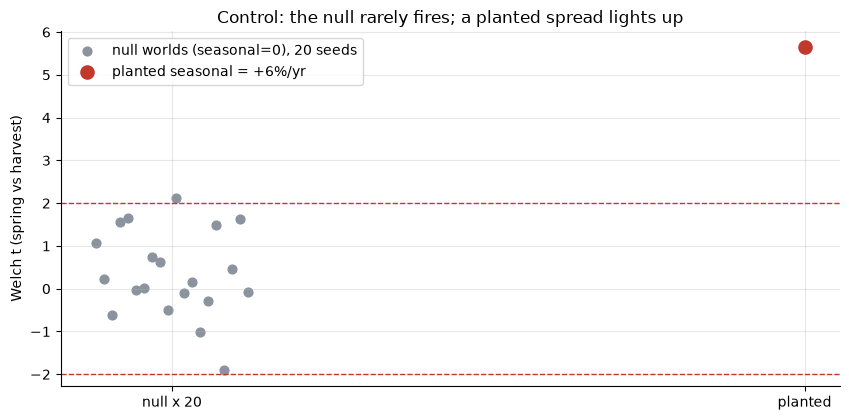

null: mean t = +0.36 (sd 1.02), |t|>=2 in 1/20 seeds  |  planted t = +5.64


In [8]:
null_ts = []
for s_ in range(20):
    df = data.synthetic_world(seasonal=0.0, seed=648 + s_)
    null_ts.append(st.synthetic_detect(df, (6, 7), (9, 10, 11))['t'])
null_ts = np.asarray(null_ts)
df = data.synthetic_world(seasonal=0.06, seed=648)
planted_t = st.synthetic_detect(df, (6, 7), (9, 10, 11))['t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (seasonal=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted seasonal = +6%/yr')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (spring vs harvest)')
ax.set_title('Control: the null rarely fires; a planted spread lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires at roughly the nominal false-positive rate (1/20 ≈ 5%, mean t = +0.36, sd 1.02) and a planted 6%/yr spread reads t = 5.64. The machinery is unbiased — the real-tape t ≈ −0.2 is the genuine article, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — pooled spring-vs-harvest spread **-0.17%/month**, Welch t = **-0.19**, bootstrap CI **[-1.97%, +1.75%]**; **0/36** grid cells clear Bonferroni; corn and soy point the wrong direction; the best month for every grain is October, inside the harvest window.
- **Tradability `MIRAGE`** — WEAT's roll drag is **-90.3 bps/month at t = -5.09**, larger and more certain than any spring/harvest spread measured; the timer's pooled net Sharpe is **-0.08**, and its apparent gross improvement is a cash-drag artifact of an already-losing basket.
- **"Beats a coin?" `BUSTED`** — active-leg hit rate **100/216 = 46.3%** (Wilson [39.8%, 53.0%]), mean per active month t = **-0.09**. Not *wrong* about the mechanism existing — wrong that it's still there, tradable, in these three ETFs, today.

## 6 · Going further

- **The mechanism could still live in the raw futures basis.** This study tests the *ETF*, not the contract-to-contract calendar spread directly. A term-structure study (front vs deferred, calendar-spread level) is the natural sequel, the way [639-gasoline-rvp-seasonality](../../639-gasoline-rvp-seasonality/) separates the curve from the holder.
- **Weather-year clustering could be masking a conditional effect** — a seasonal that only shows up in *drought* years (2012) is a different, testable claim; this study deliberately averages across all weather regimes, which is why an unconditional calendar test comes up empty even if a conditional one wouldn't.
- **Dedup map:** [307-coffee-seasonality](../../307-coffee-seasonality/) (frost, not planting), [308-cocoa-squeeze](../../308-cocoa-squeeze/) (a squeeze, not a calendar), [309-oj-frost](../../309-oj-frost/) (tail risk), [226-crude-seasonality](../../226-crude-seasonality/) / [227-natgas-winter](../../227-natgas-winter/) (energy, no storage-cycle mechanism), [639-gasoline-rvp-seasonality](../../639-gasoline-rvp-seasonality/) (a *statutory* deadline — `REAL`, unlike this study), [651-sugar-seasonality](../../651-sugar-seasonality/) (a different crush cycle).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*